
# AI Search Demo: Uninformed & Informed Strategies + Heuristics

**Nội dung:**
- Uninformed: BFS, DFS, Uniform-Cost (UCS), Bidirectional BFS
- Informed: Greedy Best-First, A* (Manhattan)
- Heuristics: admissible vs consistent, minh hoạ
- Local Search: Hill-Climbing cho N-Queens (tuỳ chọn)
- Instrumentation: số node sinh/duyệt, peak frontier, thời gian chạy
- Bài tập cho sinh viên (📘 Exercises)

> Thực thi theo từng ô từ trên xuống. Notebook tự tạo một maze lưới 2D để thử nghiệm.


## 0. Chuẩn bị môi trường

In [1]:

# Cài đặt gói nếu thiếu (chạy một lần nếu gặp lỗi import)
import networkx as nx
import pandas as pd
import random, time, math
from collections import deque
from heapq import heappush, heappop
import matplotlib.pyplot as plt

random.seed(0)


## 1. Tạo lưới maze 2D & hàm hỗ trợ

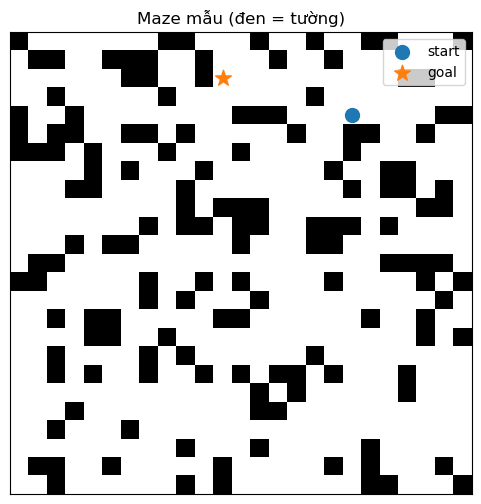

Start: (4, 18) Goal: (2, 11)


In [16]:

def make_grid(W=25, H=25, p_block=0.25, seed=0):
    """Tạo lưới HxW, 0 = trống, 1 = tường (block) với xác suất p_block."""
    rnd = random.Random(seed)
    grid = [[0]*W for _ in range(H)]
    for r in range(H):
        for c in range(W):
            if rnd.random() < p_block:
                grid[r][c] = 1
    return grid

def in_bounds(grid, rc):
    r,c = rc
    return 0 <= r < len(grid) and 0 <= c < len(grid[0])

def passable(grid, rc):
    r,c = rc
    return grid[r][c] == 0

def neighbors4(grid, rc):
    r,c = rc
    for dr,dc in [(1,0),(-1,0),(0,1),(0,-1)]:
        nr, nc = r+dr, c+dc
        if in_bounds(grid, (nr,nc)) and passable(grid, (nr,nc)):
            yield (nr,nc)

def random_free_cell(grid, rnd=None):
    rnd = rnd or random
    H, W = len(grid), len(grid[0])
    while True:
        r, c = rnd.randrange(H), rnd.randrange(W)
        if grid[r][c] == 0:
            return (r,c)

def plot_maze(grid, start=None, goal=None, path=None, title=""):
    H, W = len(grid), len(grid[0])
    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow([[1 if grid[r][c]==1 else 0 for c in range(W)] for r in range(H)], cmap="gray_r")
    if path:
        pr, pc = zip(*path)
        ax.plot(pc, pr, linewidth=2)
    if start:
        ax.scatter([start[1]], [start[0]], marker="o", s=100, label="start")
    if goal:
        ax.scatter([goal[1]], [goal[0]], marker="*", s=140, label="goal")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    if start or goal: ax.legend(loc="upper right")
    plt.show()

# Tạo một lưới mặc định để dùng thử
grid = make_grid(25,25,p_block=0.25, seed=1)
start = random_free_cell(grid, random.Random(1))
goal  = random_free_cell(grid, random.Random(2))
plot_maze(grid, start, goal, title="Maze mẫu (đen = tường)")
print("Start:", start, "Goal:", goal)


## 2. Bộ đếm thống kê (instrumentation)

In [3]:

class Stats:
    def __init__(self, name):
        self.name = name
        self.generated = 0
        self.expanded = 0
        self.peak_frontier = 0
        self.time_s = 0.0
        self.path_cost = None
        self.path_len = None

    def as_dict(self):
        return {
            "Algorithm": self.name,
            "Found": self.path_len is not None,
            "Path length": self.path_len,
            "Path cost": self.path_cost,
            "Expanded": self.expanded,
            "Generated": self.generated,
            "Peak frontier": self.peak_frontier,
            "Time (s)": round(self.time_s, 6),
        }

def reconstruct_path(parents, start, goal):
    cur = goal
    path = [cur]
    while cur != start:
        cur = parents[cur]
        path.append(cur)
    path.reverse()
    return path


## 3. Uninformed Search

In [4]:

def bfs_grid(grid, start, goal, stats=None):
    t0 = time.perf_counter()
    q = deque([start])
    parents = {start:start}
    visited = {start}
    if stats: stats.peak_frontier = max(stats.peak_frontier, len(q))
    while q:
        u = q.popleft()
        if stats: stats.expanded += 1
        if u == goal:
            if stats: stats.time_s = time.perf_counter()-t0
            return reconstruct_path(parents, start, goal)
        for v in neighbors4(grid, u):
            if v not in visited:
                visited.add(v); parents[v]=u; q.append(v)
                if stats:
                    stats.generated += 1
                    stats.peak_frontier = max(stats.peak_frontier, len(q))
    if stats: stats.time_s = time.perf_counter()-t0
    return None

def dfs_grid(grid, start, goal, stats=None):
    t0 = time.perf_counter()
    stack = [start]
    parents = {start:start}
    visited = {start}
    if stats: stats.peak_frontier = max(stats.peak_frontier, len(stack))
    while stack:
        u = stack.pop()
        if stats: stats.expanded += 1
        if u == goal:
            if stats: stats.time_s = time.perf_counter()-t0
            return reconstruct_path(parents, start, goal)
        for v in neighbors4(grid, u):
            if v not in visited:
                visited.add(v); parents[v]=u; stack.append(v)
                if stats:
                    stats.generated += 1
                    stats.peak_frontier = max(stats.peak_frontier, len(stack))
    if stats: stats.time_s = time.perf_counter()-t0
    return None

def bidir_bfs_grid(grid, start, goal, stats=None):
    if start == goal: return [start]
    t0 = time.perf_counter()
    q1, q2 = deque([start]), deque([goal])
    p1, p2 = {start:None}, {goal:None}
    vis1, vis2 = {start}, {goal}
    meet = None
    while q1 and q2 and meet is None:
        # forward
        for _ in range(len(q1)):
            u = q1.popleft()
            if stats: stats.expanded += 1
            for v in neighbors4(grid, u):
                if v not in vis1:
                    vis1.add(v); p1[v]=u; q1.append(v)
                    if v in vis2: meet = v; break
            if meet: break
        if meet: break
        # backward
        for _ in range(len(q2)):
            u = q2.popleft()
            if stats: stats.expanded += 1
            for v in neighbors4(grid, u):
                if v not in vis2:
                    vis2.add(v); p2[v]=u; q2.append(v)
                    if v in vis1: meet = v; break
            if meet: break
    if stats: stats.time_s = time.perf_counter()-t0
    if meet is None: return None
    # rebuild
    a = []; cur = meet
    while cur is not None: a.append(cur); cur = p1[cur]
    a.reverse()
    b = []; cur = p2[meet]
    while cur is not None: b.append(cur); cur = p2[cur]
    return a+b

def ucs_grid(grid, start, goal, costs=None, stats=None):
    """Uniform-Cost Search on grid with optional per-cell cost (entering cost)."""
    if costs is None:
        costs = [[1 if grid[r][c]==0 else math.inf for c in range(len(grid[0]))] for r in range(len(grid))]
    t0 = time.perf_counter()
    pq = [(0, start)]
    parents = {start:start}
    best_g = {start:0}
    if stats: stats.peak_frontier = 1
    while pq:
        g,u = heappop(pq)
        if stats: stats.expanded += 1
        if u == goal:
            if stats:
                stats.time_s = time.perf_counter()-t0
                stats.path_cost = g
            return reconstruct_path(parents, start, goal)
        if g != best_g.get(u): 
            continue
        for v in neighbors4(grid, u):
            step = costs[v[0]][v[1]]
            new_g = g + step
            if new_g < best_g.get(v, float("inf")):
                best_g[v] = new_g; parents[v]=u; heappush(pq, (new_g, v))
                if stats:
                    stats.generated += 1
                    stats.peak_frontier = max(stats.peak_frontier, len(pq))
    if stats: stats.time_s = time.perf_counter()-t0
    return None


## 4. Heuristics & Informed Search (Greedy, A*)

In [5]:

def manhattan(a,b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def greedy_best_first(grid, start, goal, h=manhattan, stats=None):
    t0 = time.perf_counter()
    pq = [(h(start,goal), start)]
    parents = {start:start}
    visited = {start}
    if stats: stats.peak_frontier = 1
    while pq:
        _, u = heappop(pq)
        if stats: stats.expanded += 1
        if u == goal:
            if stats: stats.time_s = time.perf_counter()-t0
            return reconstruct_path(parents, start, goal)
        for v in neighbors4(grid, u):
            if v not in visited:
                visited.add(v); parents[v]=u; heappush(pq, (h(v,goal), v))
                if stats:
                    stats.generated += 1
                    stats.peak_frontier = max(stats.peak_frontier, len(pq))
    if stats: stats.time_s = time.perf_counter()-t0
    return None

def astar_grid(grid, start, goal, h=manhattan, costs=None, stats=None):
    if costs is None:
        costs = [[1 if grid[r][c]==0 else math.inf for c in range(len(grid[0]))] for r in range(len(grid))]
    t0 = time.perf_counter()
    pq = [(h(start,goal), 0, start)]
    parents = {start:start}
    best_g = {start:0}
    if stats: stats.peak_frontier = 1
    while pq:
        f,g,u = heappop(pq)
        if stats: stats.expanded += 1
        if u == goal:
            if stats:
                stats.time_s = time.perf_counter()-t0
                stats.path_cost = g
            return reconstruct_path(parents, start, goal)
        if g != best_g.get(u):
            continue
        for v in neighbors4(grid,u):
            step = costs[v[0]][v[1]]
            new_g = g + step
            if new_g < best_g.get(v, float("inf")):
                best_g[v]=new_g; parents[v]=u
                heappush(pq, (new_g + h(v,goal), new_g, v))
                if stats:
                    stats.generated += 1
                    stats.peak_frontier = max(stats.peak_frontier, len(pq))
    if stats: stats.time_s = time.perf_counter()-t0
    return None


## 5. Maze có bẫy (trọng số) để so sánh UCS vs A*

In [6]:

def make_costs(grid, traps_ratio=0.1, trap_cost=5, seed=0):
    rnd = random.Random(seed)
    H,W = len(grid), len(grid[0])
    costs = [[1 if grid[r][c]==0 else math.inf for c in range(W)] for r in range(H)]
    free_cells = [(r,c) for r in range(H) for c in range(W) if grid[r][c]==0]
    rnd.shuffle(free_cells)
    n_traps = int(traps_ratio * len(free_cells))
    for r,c in free_cells[:n_traps]:
        costs[r][c] = trap_cost
    return costs

costs = make_costs(grid, traps_ratio=0.12, trap_cost=5, seed=7)
print("Ví dụ: chi phí ô start =", costs[start[0]][start[1]], ", ô goal =", costs[goal[0]][goal[1]])


Ví dụ: chi phí ô start = 1 , ô goal = 1


## 6. Chạy thử & So sánh nhanh

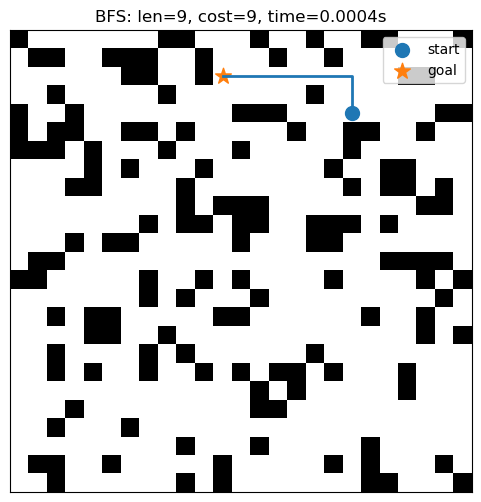

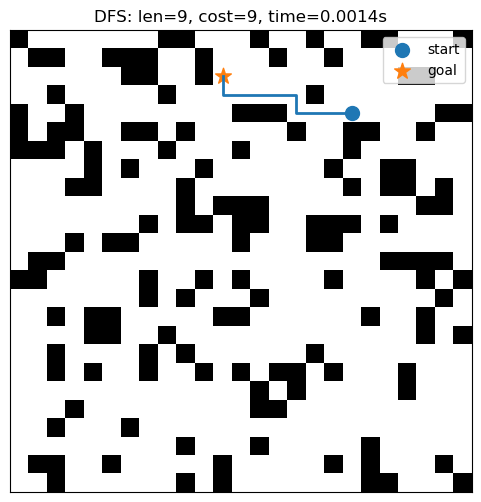

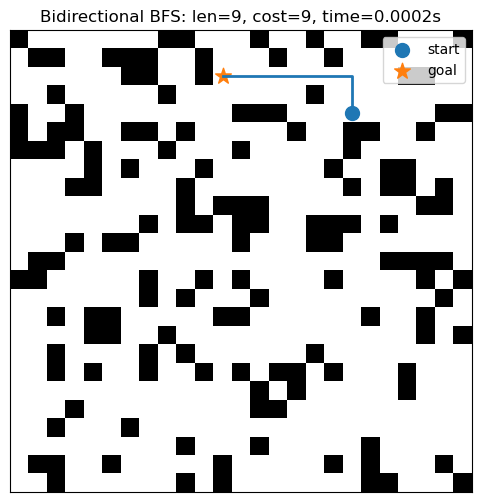

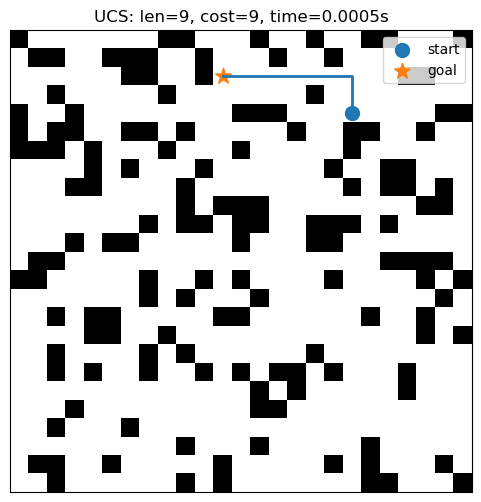

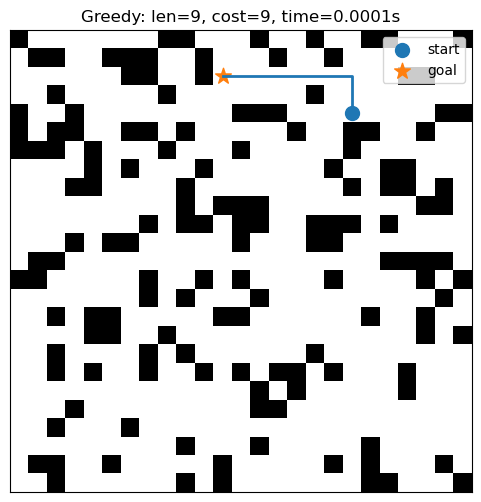

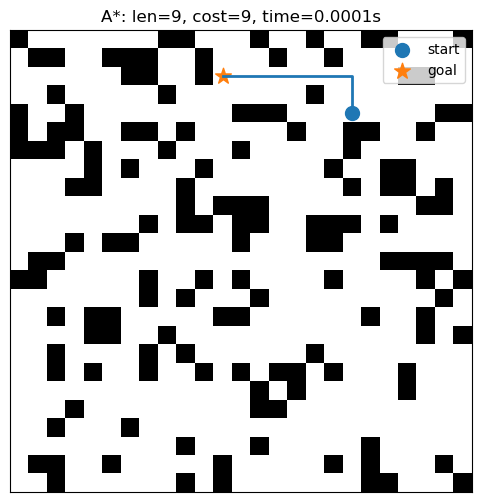

,Algorithm,Found,Path length,Path cost,Expanded,Generated,Peak frontier,Time (s)
0,BFS,True,9,9,87,100,19,0.000424
1,DFS,True,9,9,458,467,116,0.001418
2,Bidirectional BFS,True,9,9,41,0,0,0.000167
3,UCS,True,9,9,87,100,19,0.000470
4,Greedy,True,9,9,10,23,15,0.000063
5,A*,True,9,9,19,30,13,0.000149


In [11]:
algs = []
for name, fn in [
    ("BFS", bfs_grid),
    ("DFS", dfs_grid),
    ("Bidirectional BFS", bidir_bfs_grid),
    ("UCS", ucs_grid),
    ("Greedy", greedy_best_first),
    ("A*", astar_grid),
]:
    st = Stats(name)
    path = fn(grid, start, goal, stats=st)   # ✅ gọi đúng keyword
    if path:
        st.path_len = len(path)-1
        if st.path_cost is None:
            st.path_cost = sum(costs[r][c] for r,c in path[1:])
        plot_maze(grid, start, goal, path,
                  title=f"{name}: len={st.path_len}, cost={st.path_cost}, time={st.time_s:.4f}s")
    else:
        print(f"{name}: không tìm thấy đường")
    algs.append(st.as_dict())

import pandas as pd
df = pd.DataFrame(algs)
df



## 📘 Exercises (to hand in)

Thực thi các thuật toán trên
Tạo báo cáo so sánh, đánh giá các phương pháp
Có thể áp dụng các thuật toán trên vào các bài toán thực tế nào khác, tìm một ví dụ và cài đặt
